In [20]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

In [ ]:
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month

df_DA_explode = df_DA.explode('job_skills')
df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

In [ ]:
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_pivot = df_DA_pivot.drop('Total')

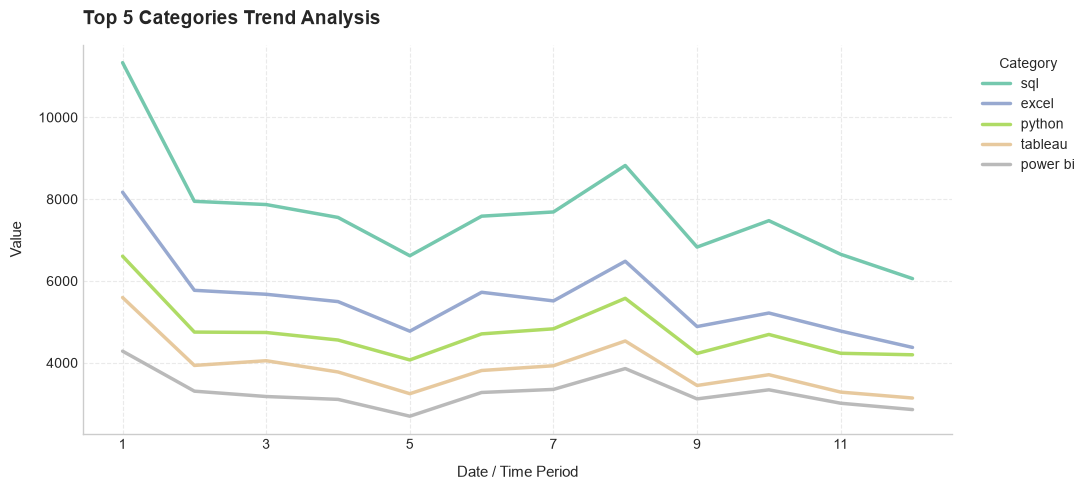

In [25]:
# Set a clean base style
plt.style.use('seaborn-v0_8-whitegrid')

# Use .iloc[:, :5] instead of .loc[:, :5]
ax = df_DA_pivot.iloc[:, :5].plot(
    kind='line',
    figsize=(11, 5),      # Wider aspect ratio
    linewidth=2.5,        # Thicker, readable lines
    colormap='Set2',      # Distinct, modern color palette
    alpha=0.9
)

# Custom Title and Axis Labels
ax.set_title('Top 5 Categories Trend Analysis', fontsize=14, fontweight='bold', loc='left', pad=15)
ax.set_xlabel('Date / Time Period', fontsize=11, labelpad=10)
ax.set_ylabel('Value', fontsize=11, labelpad=10)

# Remove harsh top and right borders (spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Lighten grid lines
ax.grid(True, linestyle='--', alpha=0.4)

# Place legend outside the plot box
ax.legend(
    title='Category', 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    frameon=False
)

plt.tight_layout()
plt.show()